# CITADEL

In [2]:
import os
import yaml
import csv
import re

def generate_summary_csv(base_dir, dataset, pruning_weights, split="test", baseline="citadel"):
    """
    CITADEL
    从多个 pruning_weight 的实验目录中提取 eval_results.txt 和 performance.yaml，
    汇总生成一个 summary.csv 文件，保存在 base_dir/results/dataset/ 下。

    参数:
        base_dir (str): 工作根目录，例如 "/data1/chenyifeng/MultiVector-Backup/dpr-scale"
        dataset (str): 数据集名称，例如 "scidocs"
        pruning_weights (list): 要处理的 pruning_weight 值列表，例如 [0.5, 0.7, 0.9, 1.1, 1.3]
        split (str): 数据集划分，默认 "test"
        baseline (str): 基线名称，默认 "citadel"
    
    返回:
        str: 生成的 CSV 文件路径，若无数据则返回 None
    """
    
    def parse_eval_results(file_path):
        """从 eval_results.txt 提取所有指标，返回字典"""
        metrics = {}
        if not os.path.exists(file_path):
            return metrics
        with open(file_path, 'r') as f:
            content = f.read()
        # 匹配形如 "NDCG@10: 0.1234" 的行
        pattern = re.compile(r'(\w+)@(\d+):\s+([\d.]+)')
        for match in pattern.finditer(content):
            metric_name = match.group(1).lower()
            k = match.group(2)
            value = float(match.group(3))
            key = f"{metric_name}_{k}"   # 例如 ndcg_10, map_100, recall_10, p_100
            metrics[key] = value
        return metrics

    def parse_performance(file_path):
        """从 performance.yaml 读取所有字段，返回字典"""
        if not os.path.exists(file_path):
            return {}
        with open(file_path, 'r') as f:
            data = yaml.safe_load(f)
        return data

    all_rows = []
    for w in pruning_weights:
        weight_str = str(w)   # 保留小数点，如 "0.5"
        eval_file = os.path.join(base_dir, "results", dataset, f"pruned_{weight_str}", "eval_results.txt")
        perf_file = os.path.join(base_dir, "retrieval", dataset, f"pruned_{weight_str}", "performance", "performance.yaml")

        metrics = parse_eval_results(eval_file)
        perf = parse_performance(perf_file)

        # 合并数据
        row = {
            "dataset": dataset,
            "split": split,
            "baseline": baseline,
            "pruning_weight": w,
            **perf,          # 展开 performance 中的所有键值
            **metrics        # 展开评估指标
        }
        all_rows.append(row)

    if not all_rows:
        print("No data found. Please check paths and pruning_weights.")
        return None

    # 收集所有出现的列名
    all_fieldnames = set()
    for row in all_rows:
        all_fieldnames.update(row.keys())

    # 排序字段：标识字段在前，其余按字母排序
    sorted_fields = ["dataset", "split", "baseline", "pruning_weight"]
    other_fields = sorted([f for f in all_fieldnames if f not in sorted_fields])
    fieldnames = sorted_fields + other_fields

    # 写入 CSV
    output_dir = os.path.join(base_dir, "results", dataset)
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, "summary.csv")

    with open(output_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(all_rows)

    print(f"Summary CSV saved to: {output_file}")
    print(f"Columns: {fieldnames}")
    return output_file

In [22]:
# plot

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_qps_pruning_metrics(csv_file, pruning_weight_list=None):
    """
    从 CSV 文件读取数据，绘制 QPS vs Recall@100 和 QPS vs MRR@100 的曲线，
    并标注每个点对应的 pruning_weight 值。

    参数:
        csv_file (str): CSV 文件的路径，必须包含 'qps', 'recall_100', 'map_100', 'pruning_weight' 列。
    
    返回:
        None，但会在 CSV 同目录下保存 PNG 图片并显示图表。
    """
    df = pd.read_csv(csv_file)

    # 过滤 pruning_weight
    if pruning_weight_list is not None:
        df = df[df['pruning_weight'].isin(pruning_weight_list)]
        
    # 如果过滤后为空，给出提示
    if df.empty:
        print("筛选后没有数据，请检查参数。")
        return

    df_sorted = df.sort_values("qps")
    
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.size'] = 12
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # ---------- 图1: QPS vs Recall@100 ----------
    ax1.plot(df_sorted["qps"], df_sorted["recall_100"], 
             marker='o', linestyle='-', linewidth=2, markersize=8, color='b')
    ax1.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax1.set_ylabel("Recall@100", fontsize=14)
    ax1.set_title("QPS vs Recall@100", fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.7)
    for _, row in df_sorted.iterrows():
        ax1.annotate(f"{row['pruning_weight']}", 
                     xy=(row["qps"], row["recall_100"]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # ---------- 图2: QPS vs MRR@100  ----------
    ax2.plot(df_sorted["qps"], df_sorted["mrr_100"], 
             marker='s', linestyle='-', linewidth=2, markersize=8, color='r')
    ax2.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax2.set_ylabel("MRR@100", fontsize=14)
    ax2.set_title("QPS vs MRR@100", fontsize=16)
    ax2.grid(True, linestyle='--', alpha=0.7)
    for _, row in df_sorted.iterrows():
        ax2.annotate(f"{row['pruning_weight']}", 
                     xy=(row["qps"], row["mrr_100"]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)

    # 设置 X 轴为对数刻度并指定刻度位置和标签
    ax1.set_xscale('log')
    ax2.set_xscale('log')
    ax1.set_xticks([1, 10, 100, 1000])
    ax1.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])
    ax2.set_xticks([1, 10, 100, 1000])
    ax2.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])
    
    plt.tight_layout()
    
    # 保存图片（与 CSV 同目录，同名 .png）
    output_dir = os.path.dirname(csv_file)
    base_name = os.path.splitext(os.path.basename(csv_file))[0]
    save_path = os.path.join(output_dir, base_name + ".png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"图片已保存为 '{save_path}'")

## Scidocs

In [1]:
cd dpr-scale

bash dataset_prepare.sh
bash generate_embeddings.sh
bash merge_embeddings.sh
bash prune_embeddings.sh
bash quantize_embeddings.sh
bash Retrieval.sh
bash Evaluation.sh

SyntaxError: invalid syntax (1059002488.py, line 1)

默认预训练权重

单gpu qps

In [ ]:
cd dpr-scale

bash beir_pipe_scidocs.sh

```
$BASE_DIR/
├── embeddings/scidocs/               
├── merged_embeddings/scidocs/
│   ├── expert/                        
│   ├── expert_pruned0.5/
│   ├── expert_pruned0.5_pq_nbits2/
│   ├── expert_pruned0.7/
│   └── ...
├── retrieval/scidocs/
│   ├── pruned_0.5/
│   │   ├── retrieval.trec
│   │   └── performance/performance.yaml
│   ├── pruned_0.7/
│   └── ...
└── results/scidocs/
    ├── pruned_0.5/
    │   └── eval_results.txt
    ├── pruned_0.7/
    └── ...
```

In [4]:
# summary

generate_summary_csv(
    base_dir="/data1/chenyifeng/MultiVector-Backup/dpr-scale",
    dataset="scidocs",
    pruning_weights=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.9]
)

Summary CSV saved to: /data1/chenyifeng/MultiVector-Backup/dpr-scale/results/scidocs/summary.csv
Columns: ['dataset', 'split', 'baseline', 'pruning_weight', 'batch_size', 'context_topk', 'cuda', 'elapsed_sec', 'map_1', 'map_10', 'map_100', 'mrr_1', 'mrr_10', 'mrr_100', 'ndcg_1', 'ndcg_10', 'ndcg_100', 'p_1', 'p_10', 'p_100', 'portion', 'qps', 'quantizer', 'query_topk', 'recall_1', 'recall_10', 'recall_100', 'sub_vec_dim', 'total_queries']


'/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/scidocs/summary.csv'

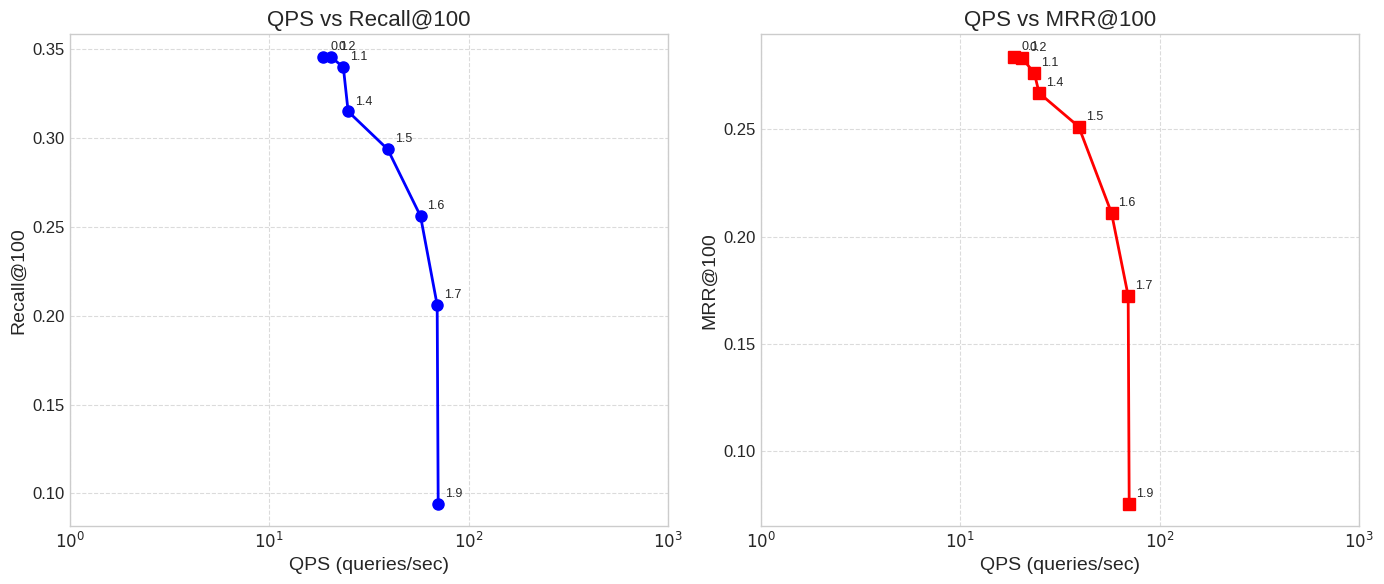

图片已保存为 '/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/scidocs/summary.png'


In [23]:
# plot

plot_qps_pruning_metrics('/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/scidocs/summary.csv',
                        pruning_weight_list=[0.1, 0.2,  1.1, 1.4, 1.5, 1.6, 1.7, 1.9 ])
# 

## Fiqa

In [ ]:
cd dpr-scale

bash beir_pipe_fiqa.sh

In [ ]:
# summary

generate_summary_csv(
    base_dir="/data1/chenyifeng/MultiVector-Backup/dpr-scale",
    dataset="fiqa",
    pruning_weights=[0.7, 1.3, 1.5, 1.9]
)

Summary CSV saved to: /data1/chenyifeng/MultiVector-Backup/dpr-scale/results/fiqa/summary.csv
Columns: ['dataset', 'split', 'baseline', 'pruning_weight', 'batch_size', 'context_topk', 'cuda', 'elapsed_sec', 'map_10', 'map_100', 'ndcg_10', 'ndcg_100', 'p_10', 'p_100', 'portion', 'qps', 'quantizer', 'query_topk', 'recall_10', 'recall_100', 'sub_vec_dim', 'total_queries']


'/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/fiqa/summary.csv'

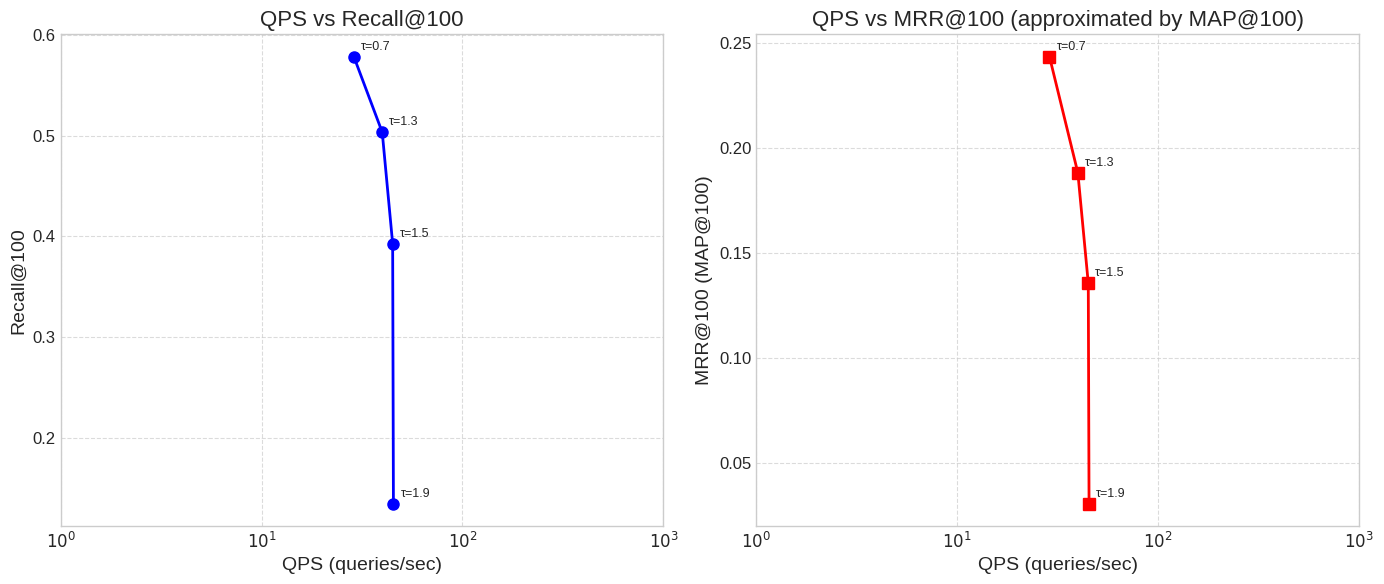

图片已保存为 '/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/fiqa/summary.png'


In [17]:
# plot

plot_qps_pruning_metrics('/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/fiqa/summary.csv',pruning_weight_list=[0.7, 1.3, 1.5, 1.9])